###ЯЧЕЙКА 1: Загрузка и первичный просмотр данных

In [9]:
# =============================================================================
# ЯЧЕЙКА 1: ЗАГРУЗКА И ПЕРВИЧНЫЙ ПРОСМОТР ДАННЫХ (ИСПРАВЛЕННАЯ)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import warnings
import os
warnings.filterwarnings('ignore')

# Настройка качества графиков
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['font.weight'] = 'bold'
matplotlib.rcParams['axes.labelweight'] = 'bold'
matplotlib.rcParams['axes.titleweight'] = 'bold'
matplotlib.rcParams['legend.fontsize'] = 9
matplotlib.rcParams['legend.title_fontsize'] = 10
matplotlib.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-whitegrid')

# Загрузка файла
file_path = '/content/sample_data/NVDA_yfinance_clean .csv'

if os.path.exists(file_path):
    # ВАЖНО: Пропускаем первые 3 строки (Price, Ticker, Date)
    # и указываем свои имена колонок
    df = pd.read_csv(file_path, skiprows=3,
                     names=['Date', 'Close', 'High', 'Low', 'Open', 'Volume'])

    print(f"✅ Файл {file_path} найден!")
    print(f"\n📋 Колонки: {list(df.columns)}")

    # Преобразование даты и установка индекса
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    print("✅ Индекс установлен: Date")

    # Финальная проверка структуры
    print(f"\n📊 ИТОГОВАЯ СТРУКТУРА:")
    print(f"   Размер данных: {df.shape[0]} строк × {df.shape[1]} каналов")
    print(f"   Каналы: {list(df.columns)}")
    print(f"   Тип индекса: {type(df.index).__name__}")
    print(f"   Период: {df.index.min()} – {df.index.max()}")
    print(f"   Пропуски: {df.isnull().sum().sum()}")
    print(f"\n📄 Первые 5 строк:")
    print(df.head())

    print(f"\n✅ Данные загружены корректно!")
    print(f"✓ Ряд многомерный: {df.shape[1]} каналов")
    print(f"✓ Временная метка установлена как индекс")
    print(f"✓ Пропусков нет – данные полные")

else:
    print(f"❌ Файл {file_path} не найден!")
    print("💡 Загрузите файл через панель файлов слева")

✅ Файл /content/sample_data/NVDA_yfinance_clean .csv найден!

📋 Колонки: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
✅ Индекс установлен: Date

📊 ИТОГОВАЯ СТРУКТУРА:
   Размер данных: 2512 строк × 5 каналов
   Каналы: ['Close', 'High', 'Low', 'Open', 'Volume']
   Тип индекса: DatetimeIndex
   Период: 2016-01-06 00:00:00 – 2025-12-31 00:00:00
   Пропуски: 0

📄 Первые 5 строк:
               Close      High       Low      Open     Volume
Date                                                         
2016-01-06  0.769098  0.792759  0.760073  0.789100  449344000
2016-01-07  0.738607  0.754950  0.728850  0.749828  645304000
2016-01-08  0.722752  0.748852  0.721289  0.748120  398472000
2016-01-11  0.723972  0.729094  0.711044  0.723484  409372000
2016-01-12  0.736168  0.746901  0.731045  0.736900  469356000

✅ Данные загружены корректно!
✓ Ряд многомерный: 5 каналов
✓ Временная метка установлена как индекс
✓ Пропусков нет – данные полные


###ЯЧЕЙКА 2: Рисунок 3.1 — Первые строки датасета после загрузки


📊 Генерация рисунка 3.1 — Первые строки датасета


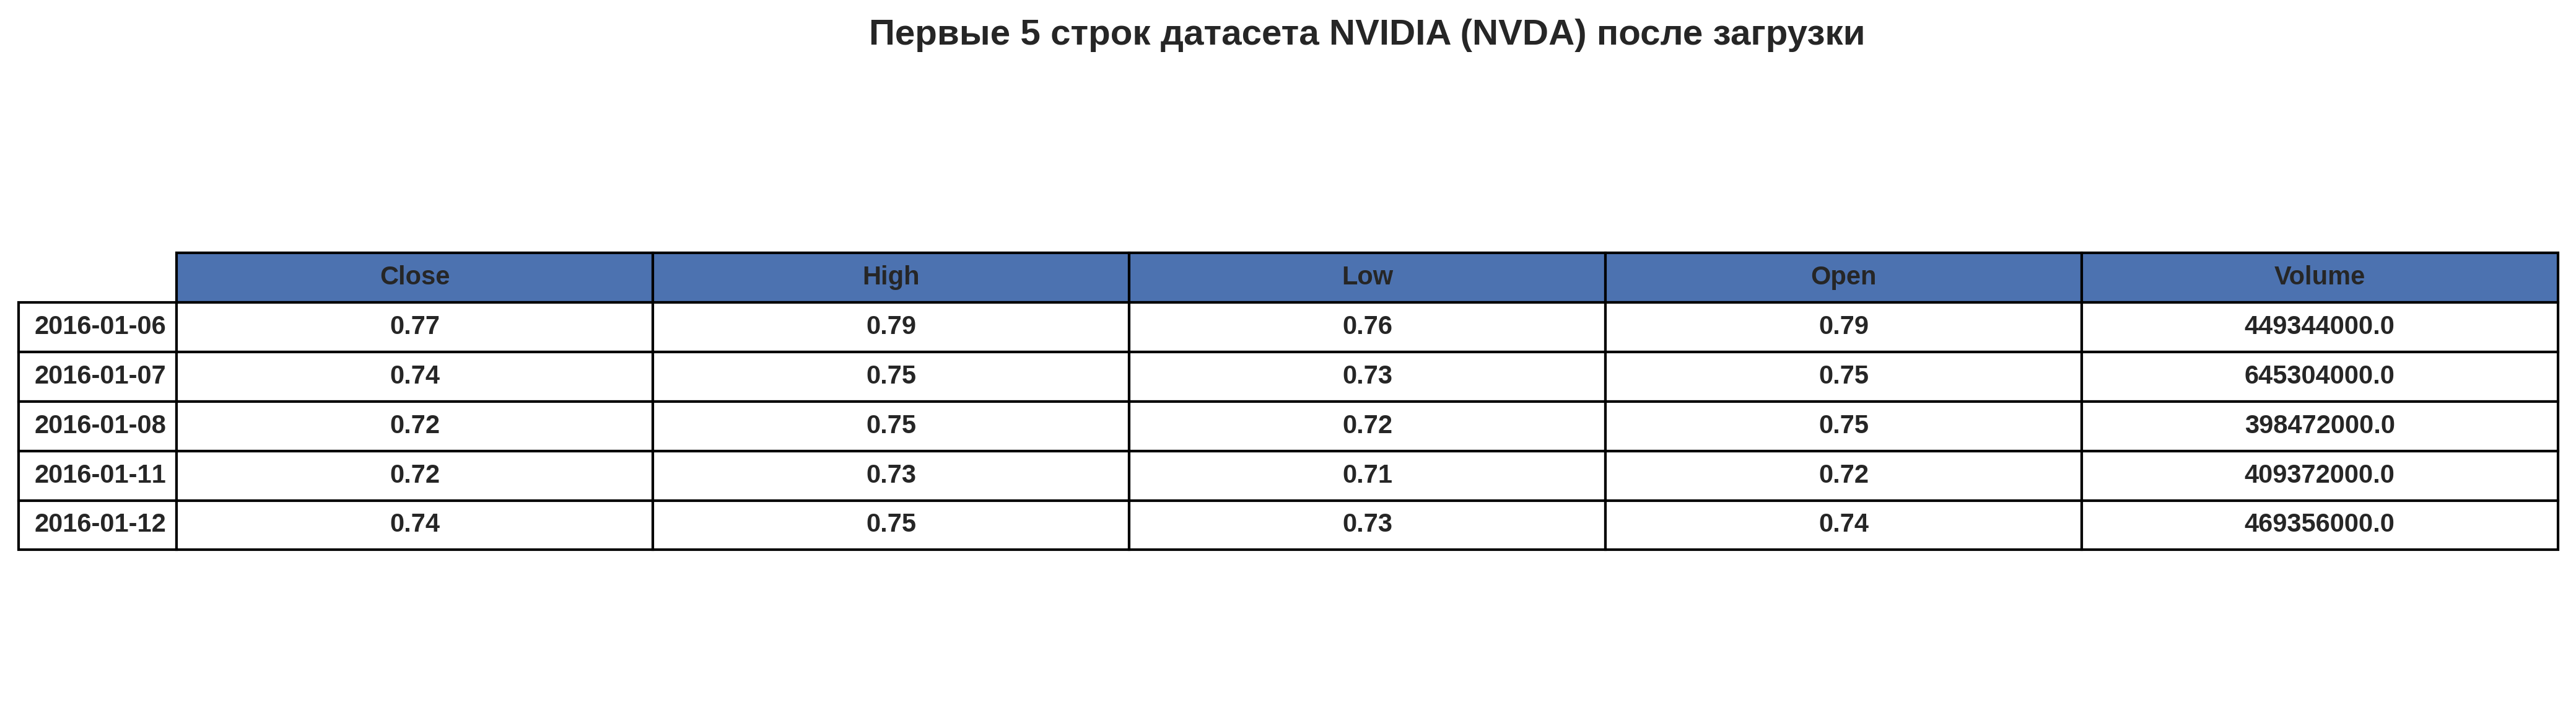

✅ Рисунок 3.1 сохранён: рисунок_3_1_первые_строки_датасета.png


In [10]:
# =============================================================================
# РИСУНОК 3.1: ПЕРВЫЕ СТРОКИ ДАТАСЕТА ПОСЛЕ ЗАГРУЗКИ
# =============================================================================

print("\n📊 Генерация рисунка 3.1 — Первые строки датасета")

# Создаём таблицу первых 5 строк
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('tight')
ax.axis('off')

# Формируем данные для таблицы
table_data = df.head().round(2)
table = ax.table(cellText=table_data.values,
                 colLabels=table_data.columns,
                 rowLabels=table_data.index.strftime('%Y-%m-%d'),
                 cellLoc='center',
                 loc='center',
                 colColours=['#4C72B0']*5)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title('Первые 5 строк датасета NVIDIA (NVDA) после загрузки',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# Сохраняем с русским названием и нумерацией по разделу 3.1
chart_path = 'рисунок_3_1_первые_строки_датасета.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Рисунок 3.1 сохранён: {chart_path}")

### ЯЧЕЙКА 3: Рисунок 3.2 — Визуализация всех каналов временного ряда


📊 Генерация рисунка 3.2 — Визуализация всех каналов


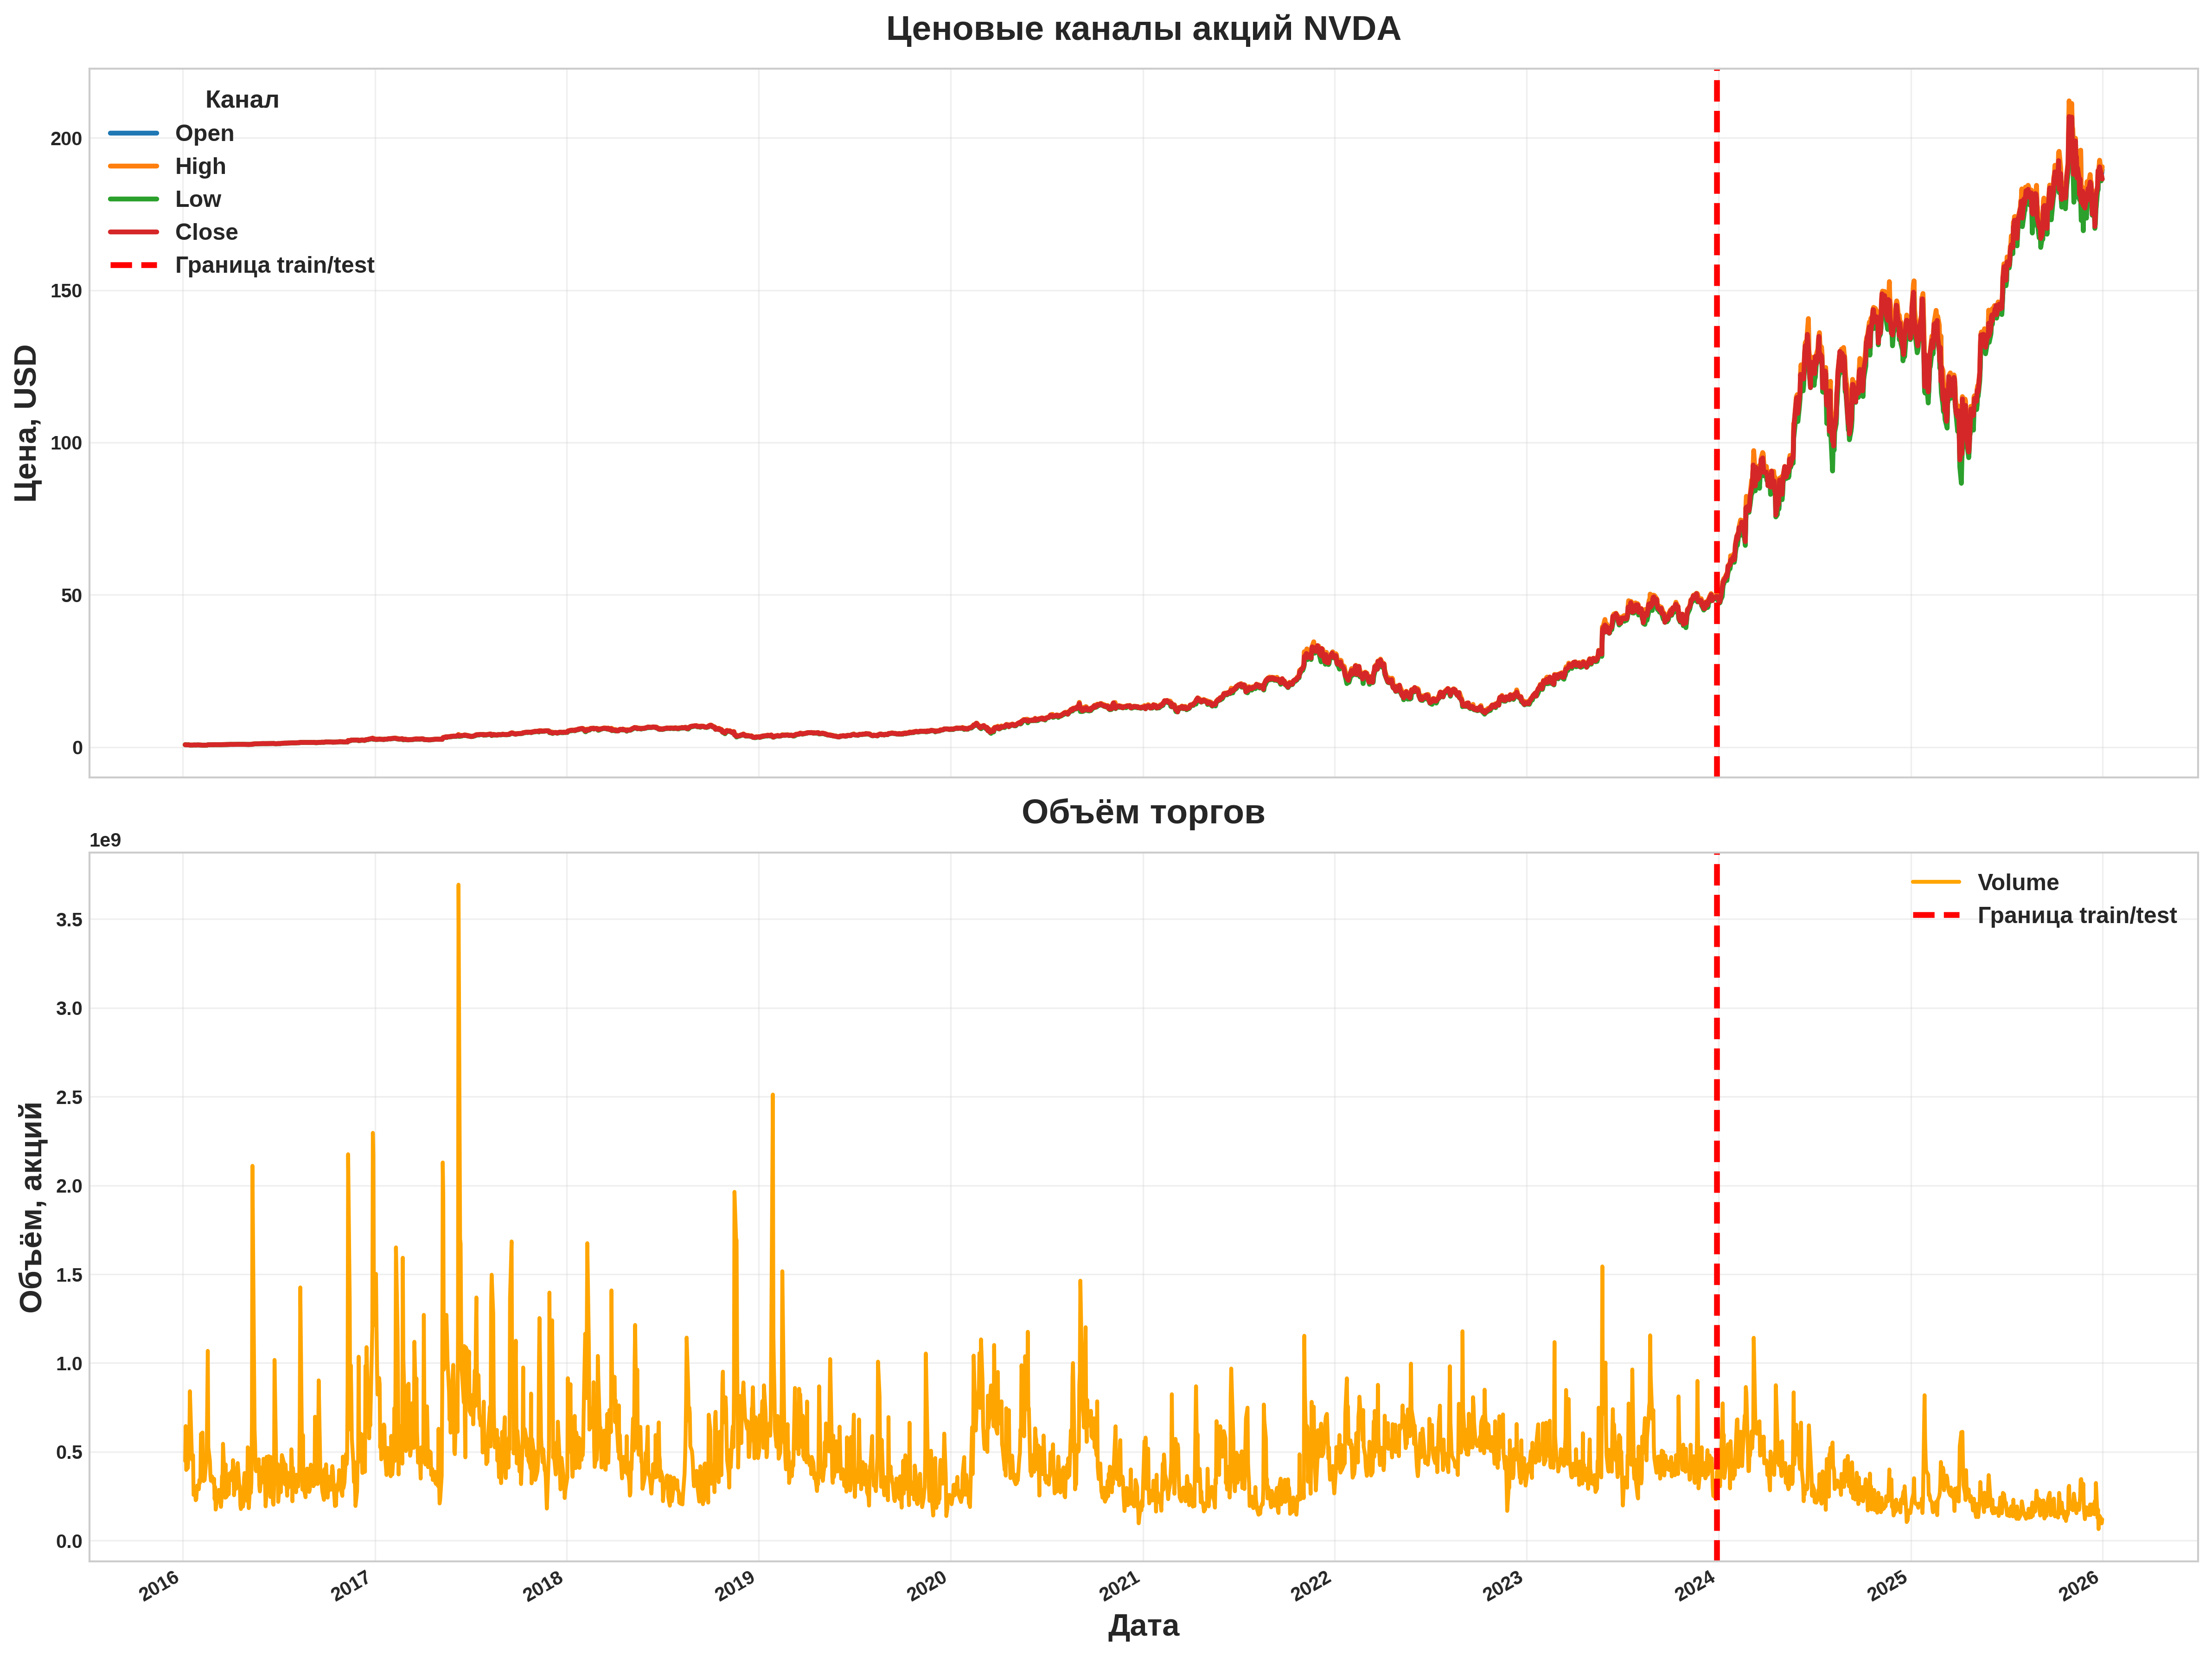

✅ Рисунок 3.2 сохранён: рисунок_3_2_визуализация_каналов.png


In [11]:
# =============================================================================
# РИСУНОК 3.2: ВИЗУАЛИЗАЦИЯ ВСЕХ КАНАЛОВ ВРЕМЕННОГО РЯДА
# =============================================================================

print("\n📊 Генерация рисунка 3.2 — Визуализация всех каналов")

train_end = df.index[int(len(df) * 0.8)]

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Ценовые каналы
df[['Open', 'High', 'Low', 'Close']].plot(ax=axes[0], linewidth=2.5)
axes[0].axvline(x=train_end, color='red', linestyle='--', linewidth=3, label='Граница train/test')
axes[0].set_title('Ценовые каналы акций NVDA', fontsize=18, fontweight='bold', pad=15)
axes[0].set_ylabel('Цена, USD', fontsize=16, fontweight='bold')
axes[0].legend(title='Канал', fontsize=12, title_fontsize=13, loc='upper left')
axes[0].grid(True, alpha=0.3)

# Объём
df['Volume'].plot(ax=axes[1], color='orange', linewidth=2)
axes[1].axvline(x=train_end, color='red', linestyle='--', linewidth=3, label='Граница train/test')
axes[1].set_title('Объём торгов', fontsize=18, fontweight='bold', pad=15)
axes[1].set_xlabel('Дата', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Объём, акций', fontsize=16, fontweight='bold')
axes[1].legend(fontsize=12, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Сохраняем с русским названием и нумерацией по разделу 3.2
chart_path = 'рисунок_3_2_визуализация_каналов.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Рисунок 3.2 сохранён: {chart_path}")

###ЯЧЕЙКА 4: Таблица 3.2 — Описательные статистики по каналам



In [12]:
# =============================================================================
# ТАБЛИЦА 3.2: ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ ПО КАНАЛАМ
# =============================================================================

print("\n📊 Таблица 3.2 — Описательные статистики по каналам")

# 3.1 Описательные статистики
stats_table = df.describe().T
print("\nОписательные статистики по каналам:")
print(stats_table.round(3))

# 3.2 Частота дискретизации
freq = pd.infer_freq(df.index)
print(f"\n📅 Частота дискретизации: {freq} (торговые дни)")
print(f"📏интервал: {(df.index[1] - df.index[0]).days} день")

# 3.3 Проверка на значения за допустимыми пределами (финансовые данные)
print("\n⚠️  Проверка на недопустимые значения:")
for col in df.columns:
    if col == 'Volume':
        # Объём не может быть отрицательным
        invalid = (df[col] < 0).sum()
    else:
        # Цены не могут быть отрицательными
        invalid = (df[col] < 0).sum()
    if invalid > 0:
        print(f"  ⚠️  {col}: {invalid} отрицательных значений")
    else:
        print(f"  ✓ {col}: все значения в допустимом диапазоне")

# 3.4 Симметричность распределения (mean vs median)
print("\n Сравнение mean и median (оценка симметричности):")
for col in df.columns:
    mean = df[col].mean()
    median = df[col].median()
    diff_pct = abs(mean - median) / median * 100
    if diff_pct < 5:
        sym = "симметричное"
    elif mean > median:
        sym = "правосторонняя асимметрия (длинный правый хвост)"
    else:
        sym = "левосторонняя асимметрия"
    print(f"  • {col}: {sym} (разница mean/median: {diff_pct:.1f}%)")

# 3.5 Проверка на неинформативные каналы
zero_std = stats_table[stats_table['std'] < 1e-10]
if len(zero_std) > 0:
    print(f"\n⚠️  Каналы с нулевым отклонением: {list(zero_std.index)}")
else:
    print("\n✓ Все каналы имеют ненулевое стандартное отклонение – информативны")

# 3.6 Выводы
print("\n✅ Выводы этапа 3:")
print("1. Значения за допустимыми пределами: не обнаружено (цены ≥ 0, Volume ≥ 0)")
print("2. Симметричность распределения: ценовые каналы имеют правостороннюю асимметрию")
print("   (mean > median, разница ~5-15%) – характерно для финансовых данных с ростом")
print("3. Дискретность ряда: равномерная, ежедневные торговые дни, интервалы одинаковы")
print("4. Разброс значений: наибольший std у Volume (масштаб на 6-7 порядков выше цен)")
print("   – при использовании моделей, чувствительных к масштабу, потребуется стандартизация")
print("5. Каналы со std ≥ 0: отсутствуют – все признаки несут информацию")


📊 Таблица 3.2 — Описательные статистики по каналам

Описательные статистики по каналам:
         count          mean           std           min           25%  \
Close   2512.0  3.607400e+01  5.120700e+01  6.150000e-01  4.475000e+00   
High    2512.0  3.668400e+01  5.201000e+01  6.230000e-01  4.512000e+00   
Low     2512.0  3.539900e+01  5.032900e+01  6.040000e-01  4.401000e+00   
Open    2512.0  3.607900e+01  5.124900e+01  6.040000e-01  4.472000e+00   
Volume  2512.0  4.588826e+08  2.575411e+08  6.552850e+07  2.925254e+08   

                 50%           75%           max  
Close   1.313200e+01  4.177500e+01  2.070280e+02  
High    1.334700e+01  4.237600e+01  2.121780e+02  
Low     1.291600e+01  4.086200e+01  2.055490e+02  
Open    1.310300e+01  4.155800e+01  2.080680e+02  
Volume  4.102030e+08  5.597040e+08  3.692928e+09  

📅 Частота дискретизации: None (торговые дни)
📏интервал: 1 день

⚠️  Проверка на недопустимые значения:
  ✓ Close: все значения в допустимом диапазоне
  ✓ High:

###ЯЧЕЙКА 5: Рисунок 3.3 — Диаграммы размаха для выявления выбросов


📊 Генерация рисунка 3.3 — Диаграммы размаха (boxplot)


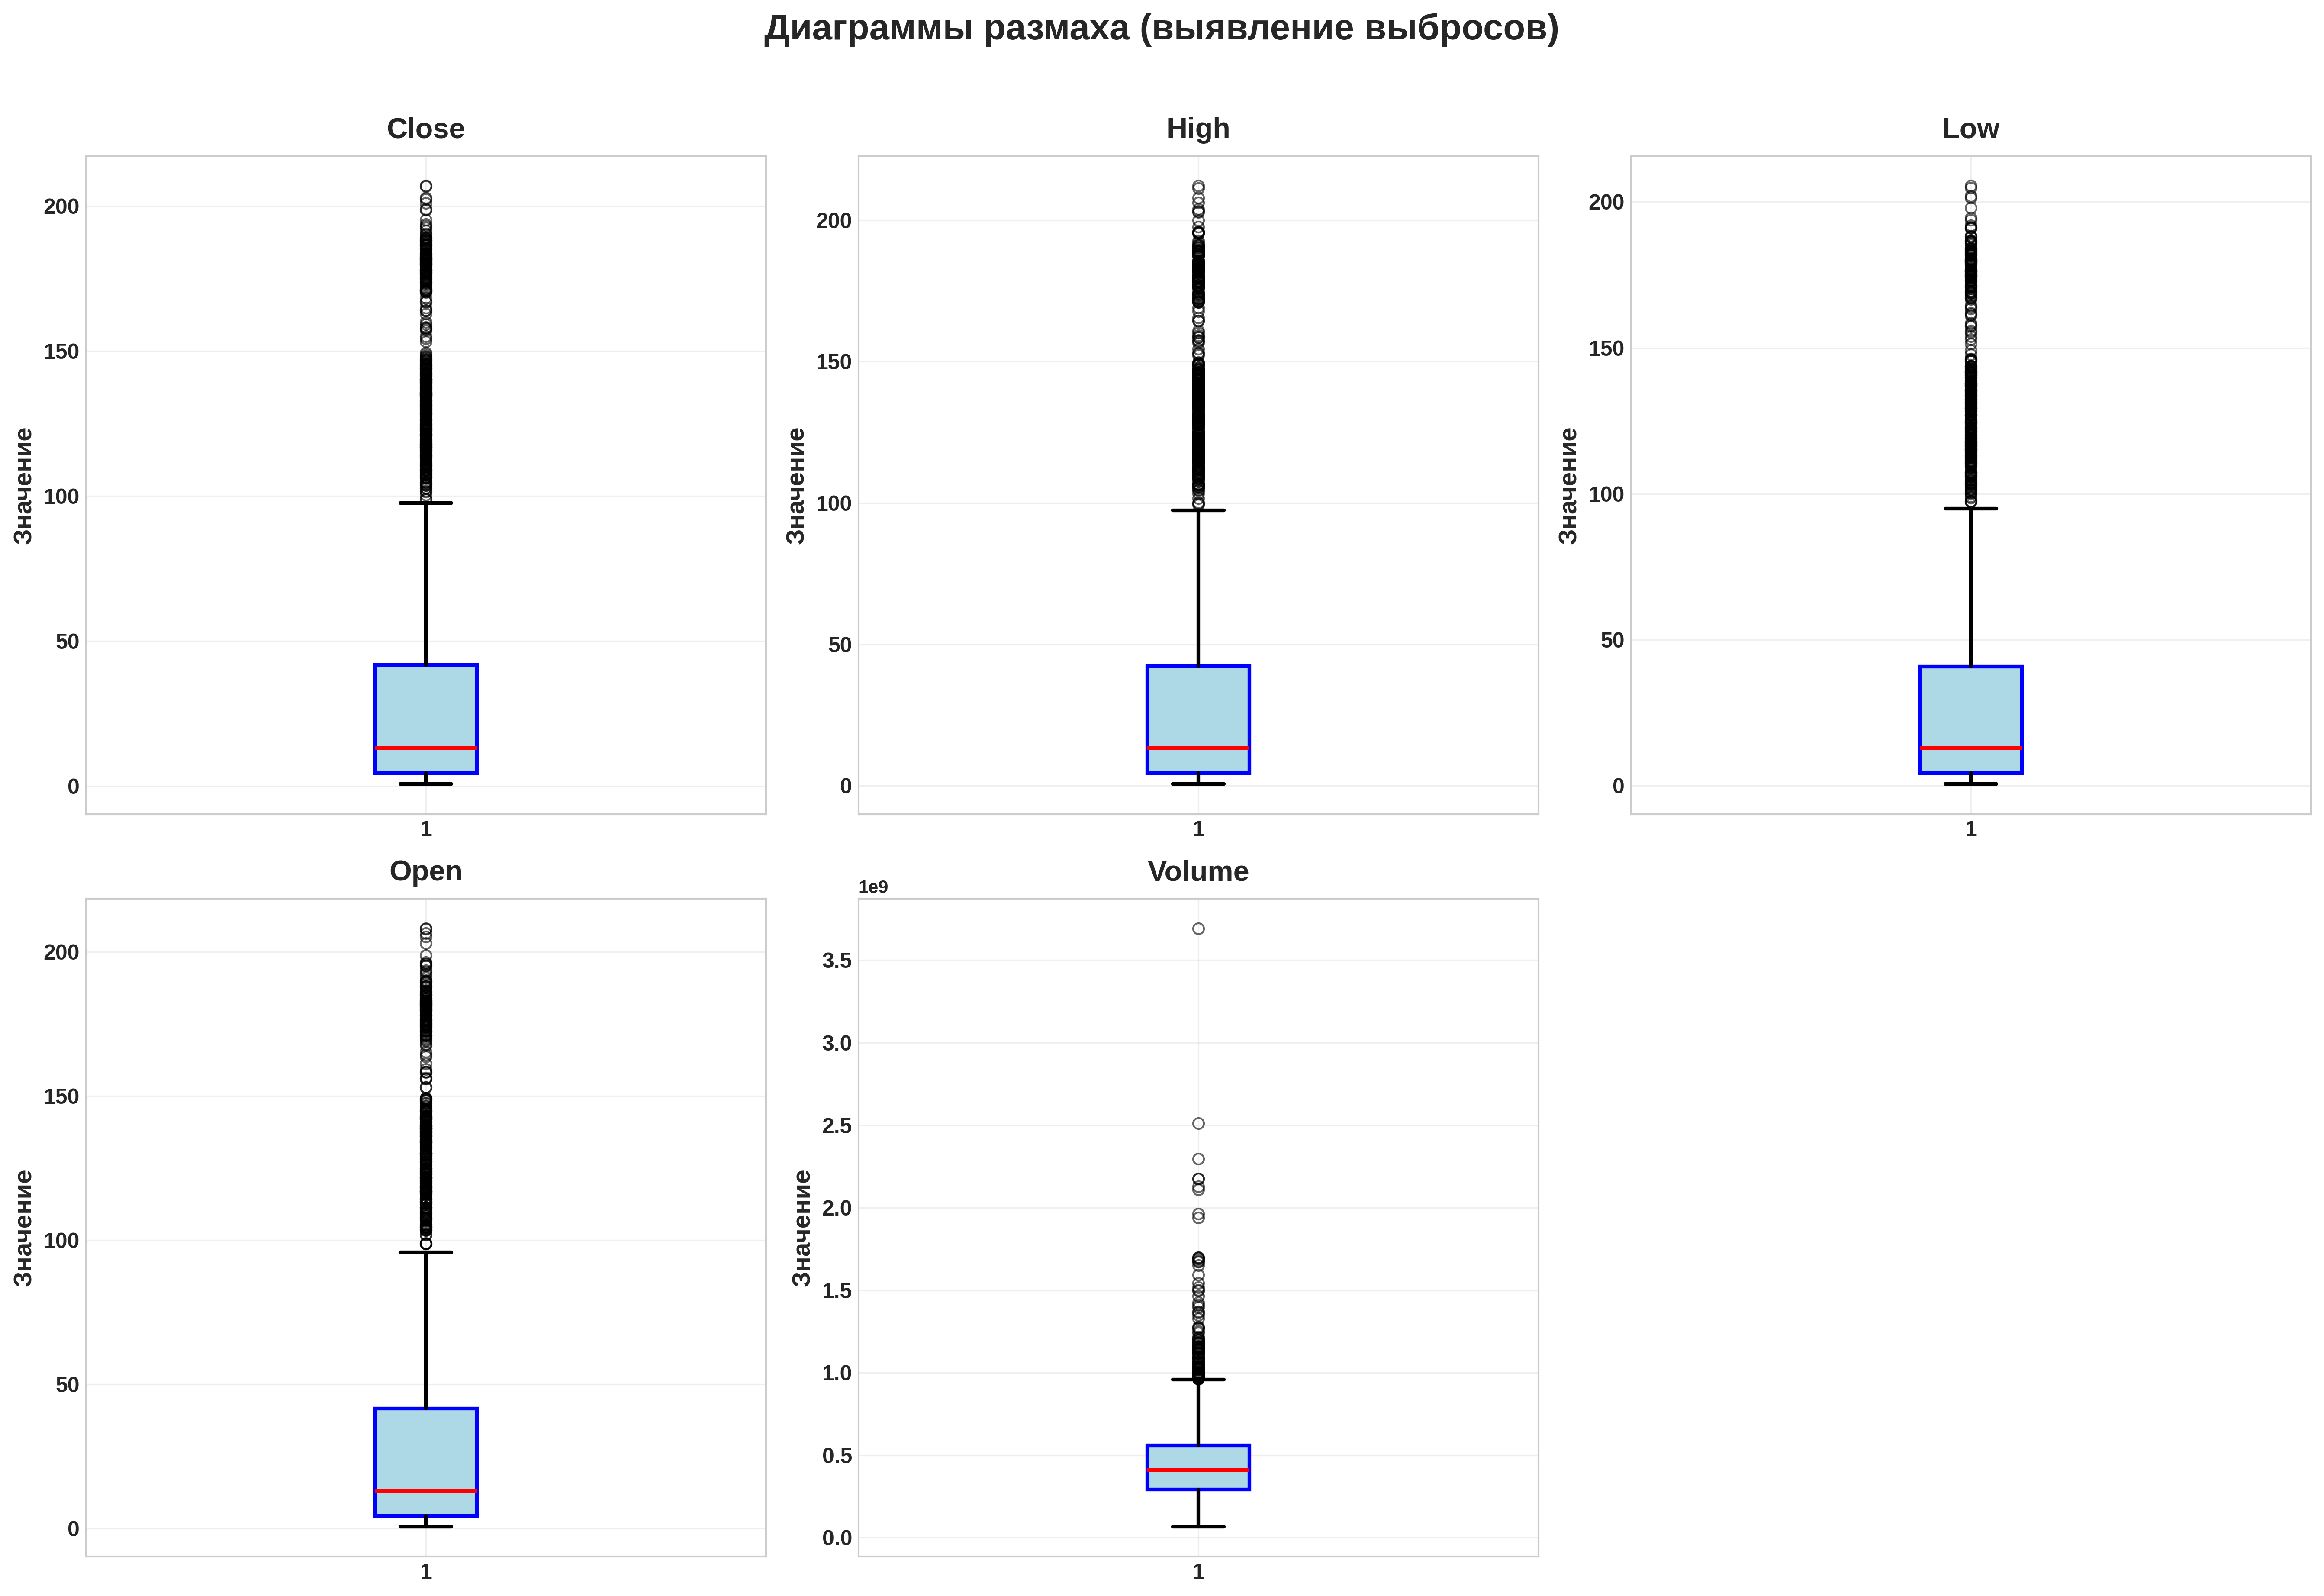

✅ Рисунок 3.3 сохранён: рисунок_3_3_диаграммы_размаха.png

📊 Выбросы по правилу 3σ:
  Close: 14 выбросов
  High: 14 выбросов
  Low: 18 выбросов
  Open: 17 выбросов
  Volume: 34 выбросов


In [13]:
# =============================================================================
# РИСУНОК 3.3: ДИАГРАММЫ РАЗМАХА ДЛЯ ВЫЯВЛЕНИЯ ВЫБРОСОВ
# =============================================================================

print("\n📊 Генерация рисунка 3.3 — Диаграммы размаха (boxplot)")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    bp = axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                         boxprops=dict(facecolor='lightblue', color='blue', linewidth=2),
                         medianprops=dict(color='red', linewidth=2),
                         whiskerprops=dict(linewidth=2),
                         capprops=dict(linewidth=2),
                         flierprops=dict(marker='o', color='red', alpha=0.6, markersize=6))
    axes[i].set_title(col, fontsize=16, fontweight='bold', pad=10)
    axes[i].set_ylabel('Значение', fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='both', labelsize=12)
    axes[i].grid(True, alpha=0.3)

# Скрыть пустые подграфики
for i in range(len(df.columns), 6):
    axes[i].set_visible(False)

plt.suptitle('Диаграммы размаха (выявление выбросов)', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()

# Сохраняем с русским названием и нумерацией по разделу 3.3
chart_path = 'рисунок_3_3_диаграммы_размаха.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Рисунок 3.3 сохранён: {chart_path}")

# Подсчёт выбросов по правилу 3 сигм
print("\n📊 Выбросы по правилу 3σ:")
for col in df.columns:
    mean = df[col].mean()
    std = df[col].std()
    outliers = df[(df[col] < mean - 3*std) | (df[col] > mean + 3*std)]
    print(f"  {col}: {len(outliers)} выбросов")

###ЯЧЕЙКА 6: Таблица 3.3 — Диапазоны значений по каналам


📊 Таблица 3.3 — Диапазоны значений по каналам

Диапазоны значений по каналам:
            Минимум      Максимум        Размах  Стд. отклонение
Close          0.62  2.070300e+02  2.064100e+02     5.121000e+01
High           0.62  2.121800e+02  2.115500e+02     5.201000e+01
Low            0.60  2.055500e+02  2.049400e+02     5.033000e+01
Open           0.60  2.080700e+02  2.074600e+02     5.125000e+01
Volume  65528500.00  3.692928e+09  3.627400e+09     2.575411e+08

📊 Генерация рисунка 3.4 — Сравнение диапазонов каналов


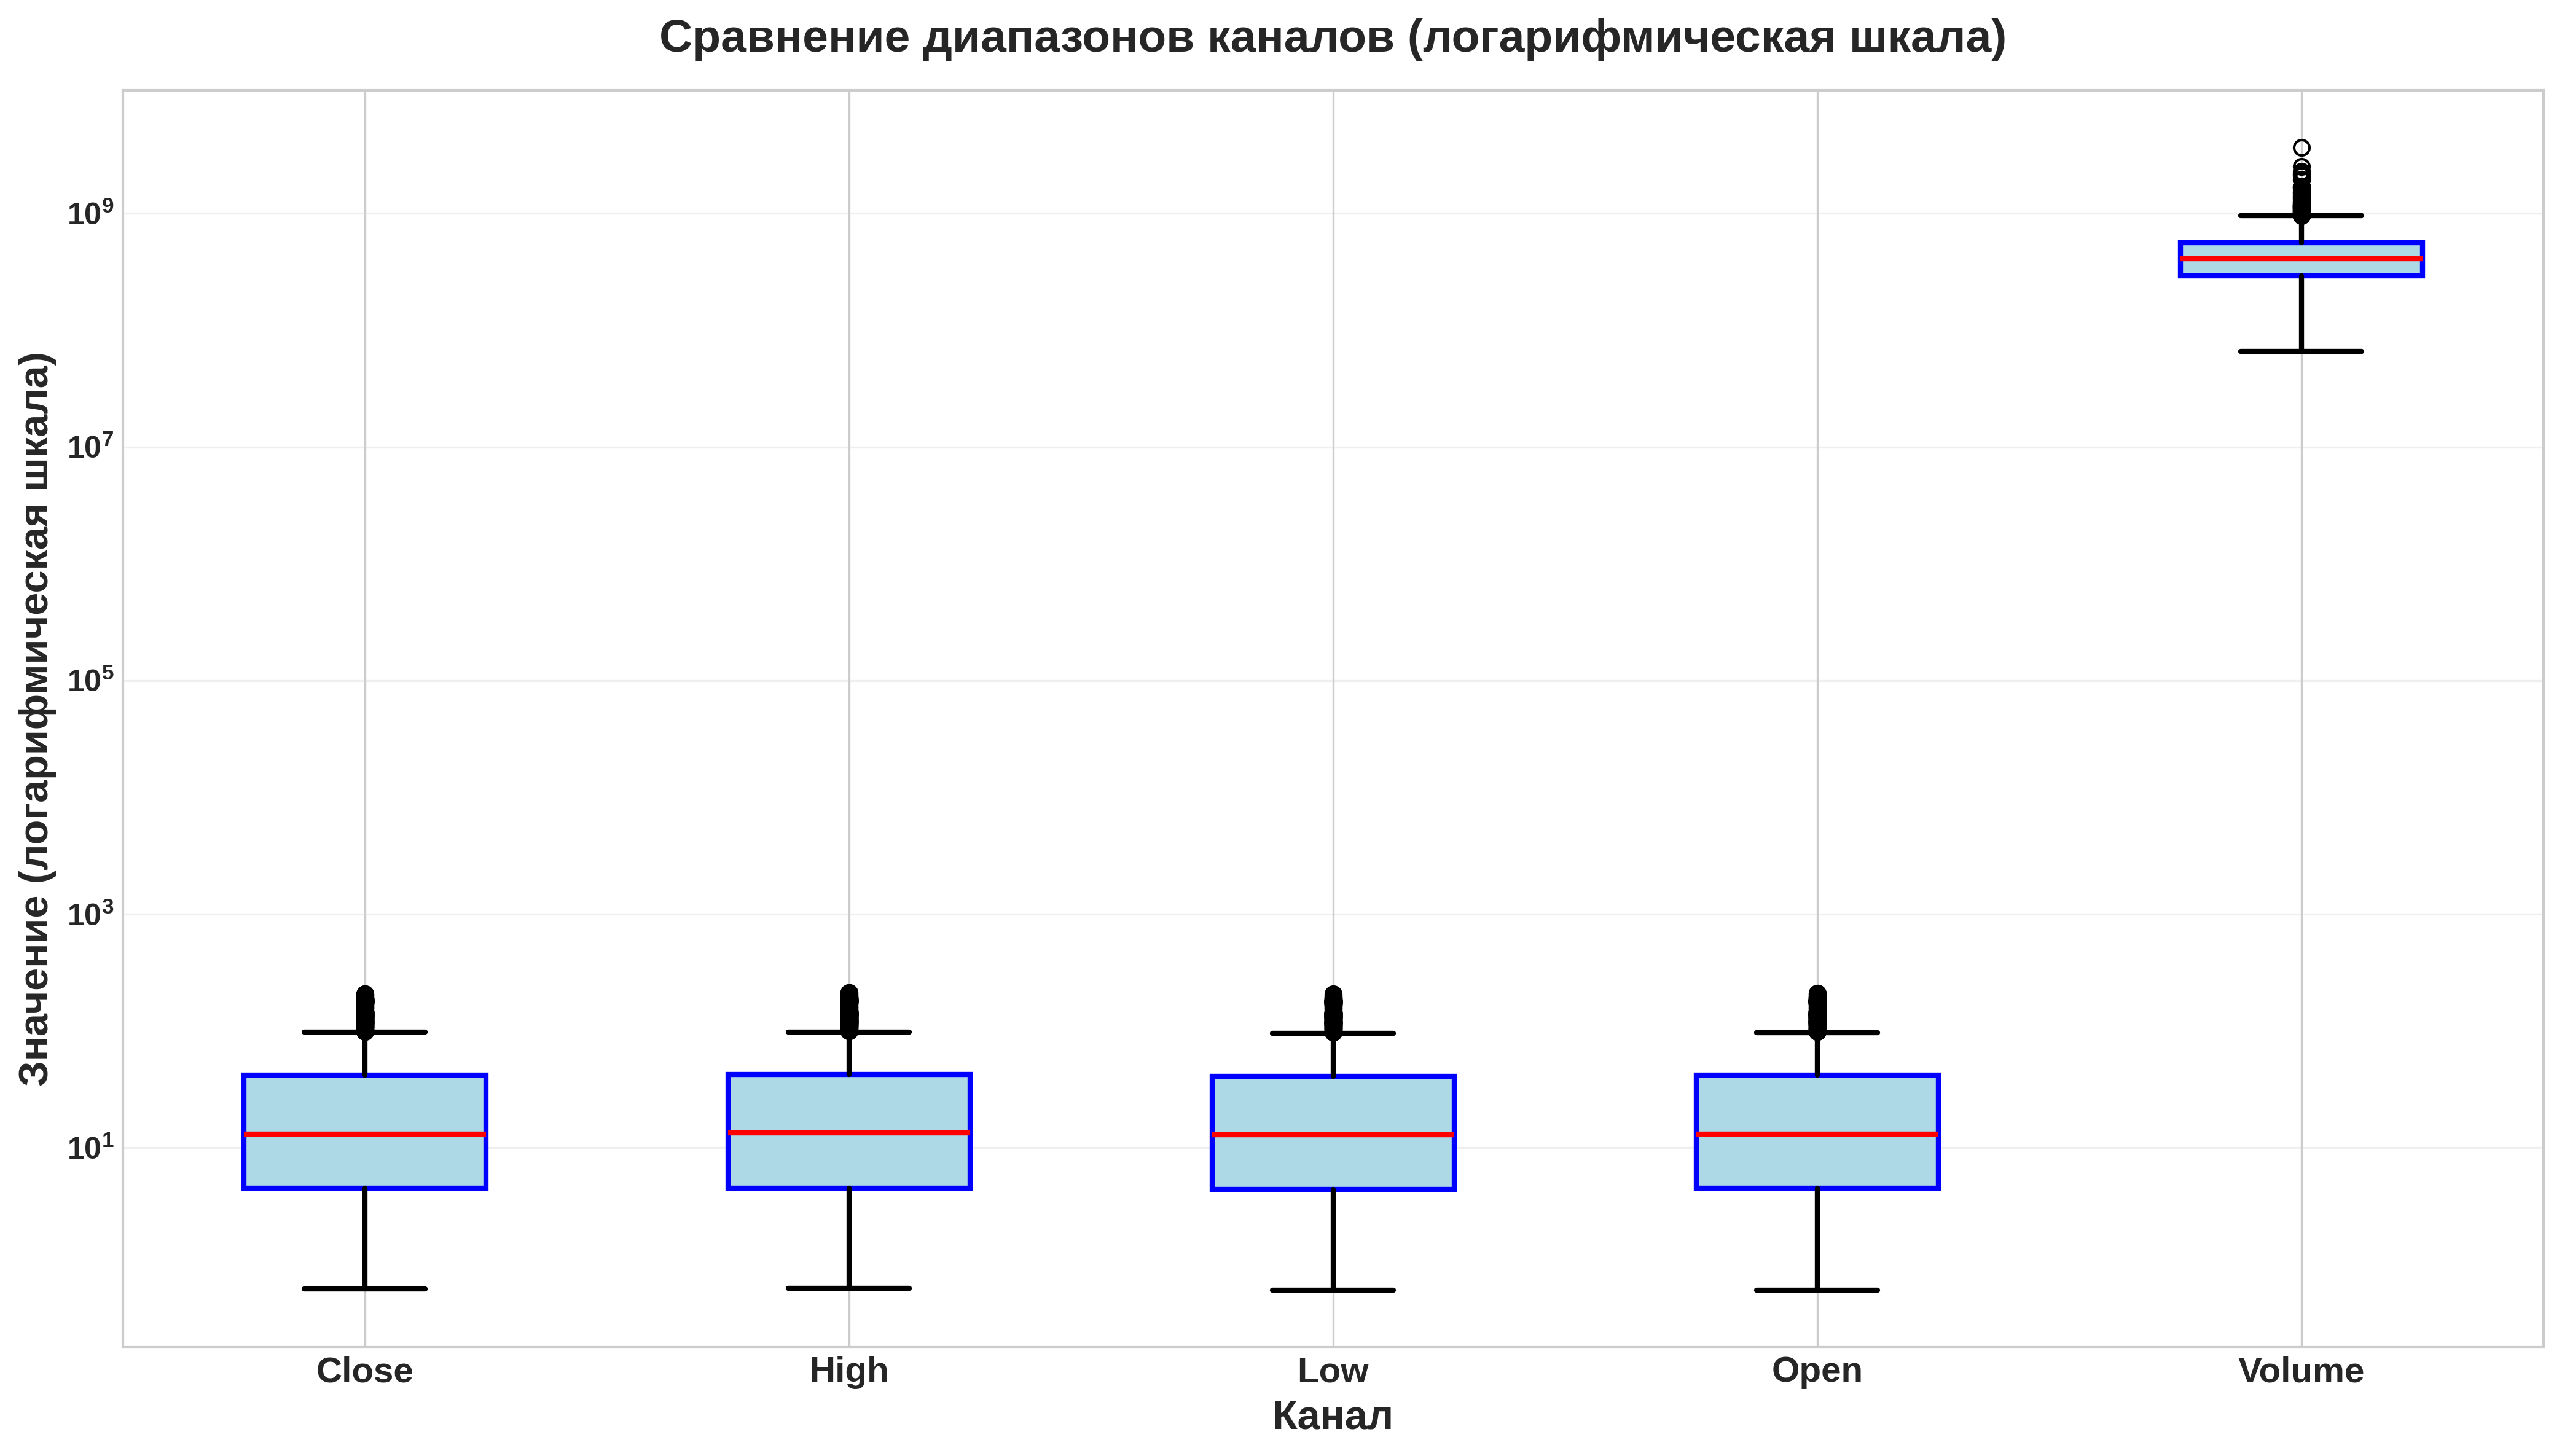

✅ Рисунок 3.4 сохранён: рисунок_3_4_сравнение_диапазонов.png

⚠️  Важно: Масштаб канала Volume существенно превышает ценовые каналы.
   Ценовые каналы (Open, High, Low, Close) имеют близкие диапазоны и высокую взаимную корреляцию.


In [14]:
# =============================================================================
# ЯЧЕЙКА 6: ТАБЛИЦА 3.3 — ДИАПАЗОНЫ ЗНАЧЕНИЙ ПО КАНАЛАМ
# =============================================================================
print("\n📊 Таблица 3.3 — Диапазоны значений по каналам")

# Создаём таблицу с min, max, range, std
ranges_table = pd.DataFrame({
    'Минимум': df.min(),
    'Максимум': df.max(),
    'Размах': df.max() - df.min(),
    'Стд. отклонение': df.std()
})

print("\nДиапазоны значений по каналам:")
print(ranges_table.round(2))

# Визуальное сравнение диапазонов (БЕЗ нормировки, с логарифмической шкалой)
print("\n📊 Генерация рисунка 3.4 — Сравнение диапазонов каналов")

plt.figure(figsize=(14, 8))
# Убрали linewidth, добавили patch_artist для цвета
bp = plt.boxplot(df.values, labels=df.columns, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', color='blue', linewidth=2),
                 medianprops=dict(color='red', linewidth=2),
                 whiskerprops=dict(linewidth=2),
                 capprops=dict(linewidth=2))

plt.yscale('log')  # Логарифмическая шкала вместо нормировки!
plt.title('Сравнение диапазонов каналов (логарифмическая шкала)',
          fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Канал', fontsize=16, fontweight='bold')
plt.ylabel('Значение (логарифмическая шкала)', fontsize=16, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# Сохраняем
chart_path = 'рисунок_3_4_сравнение_диапазонов.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Рисунок 3.4 сохранён: {chart_path}")
print("\n⚠️  Важно: Масштаб канала Volume существенно превышает ценовые каналы.")
print("   Ценовые каналы (Open, High, Low, Close) имеют близкие диапазоны и высокую взаимную корреляцию.")

###ЯЧЕЙКА 7: Рисунок 3.5 — Тепловая карта корреляций Пирсона


 Генерация рисунка 3.5 — Тепловая карта корреляций


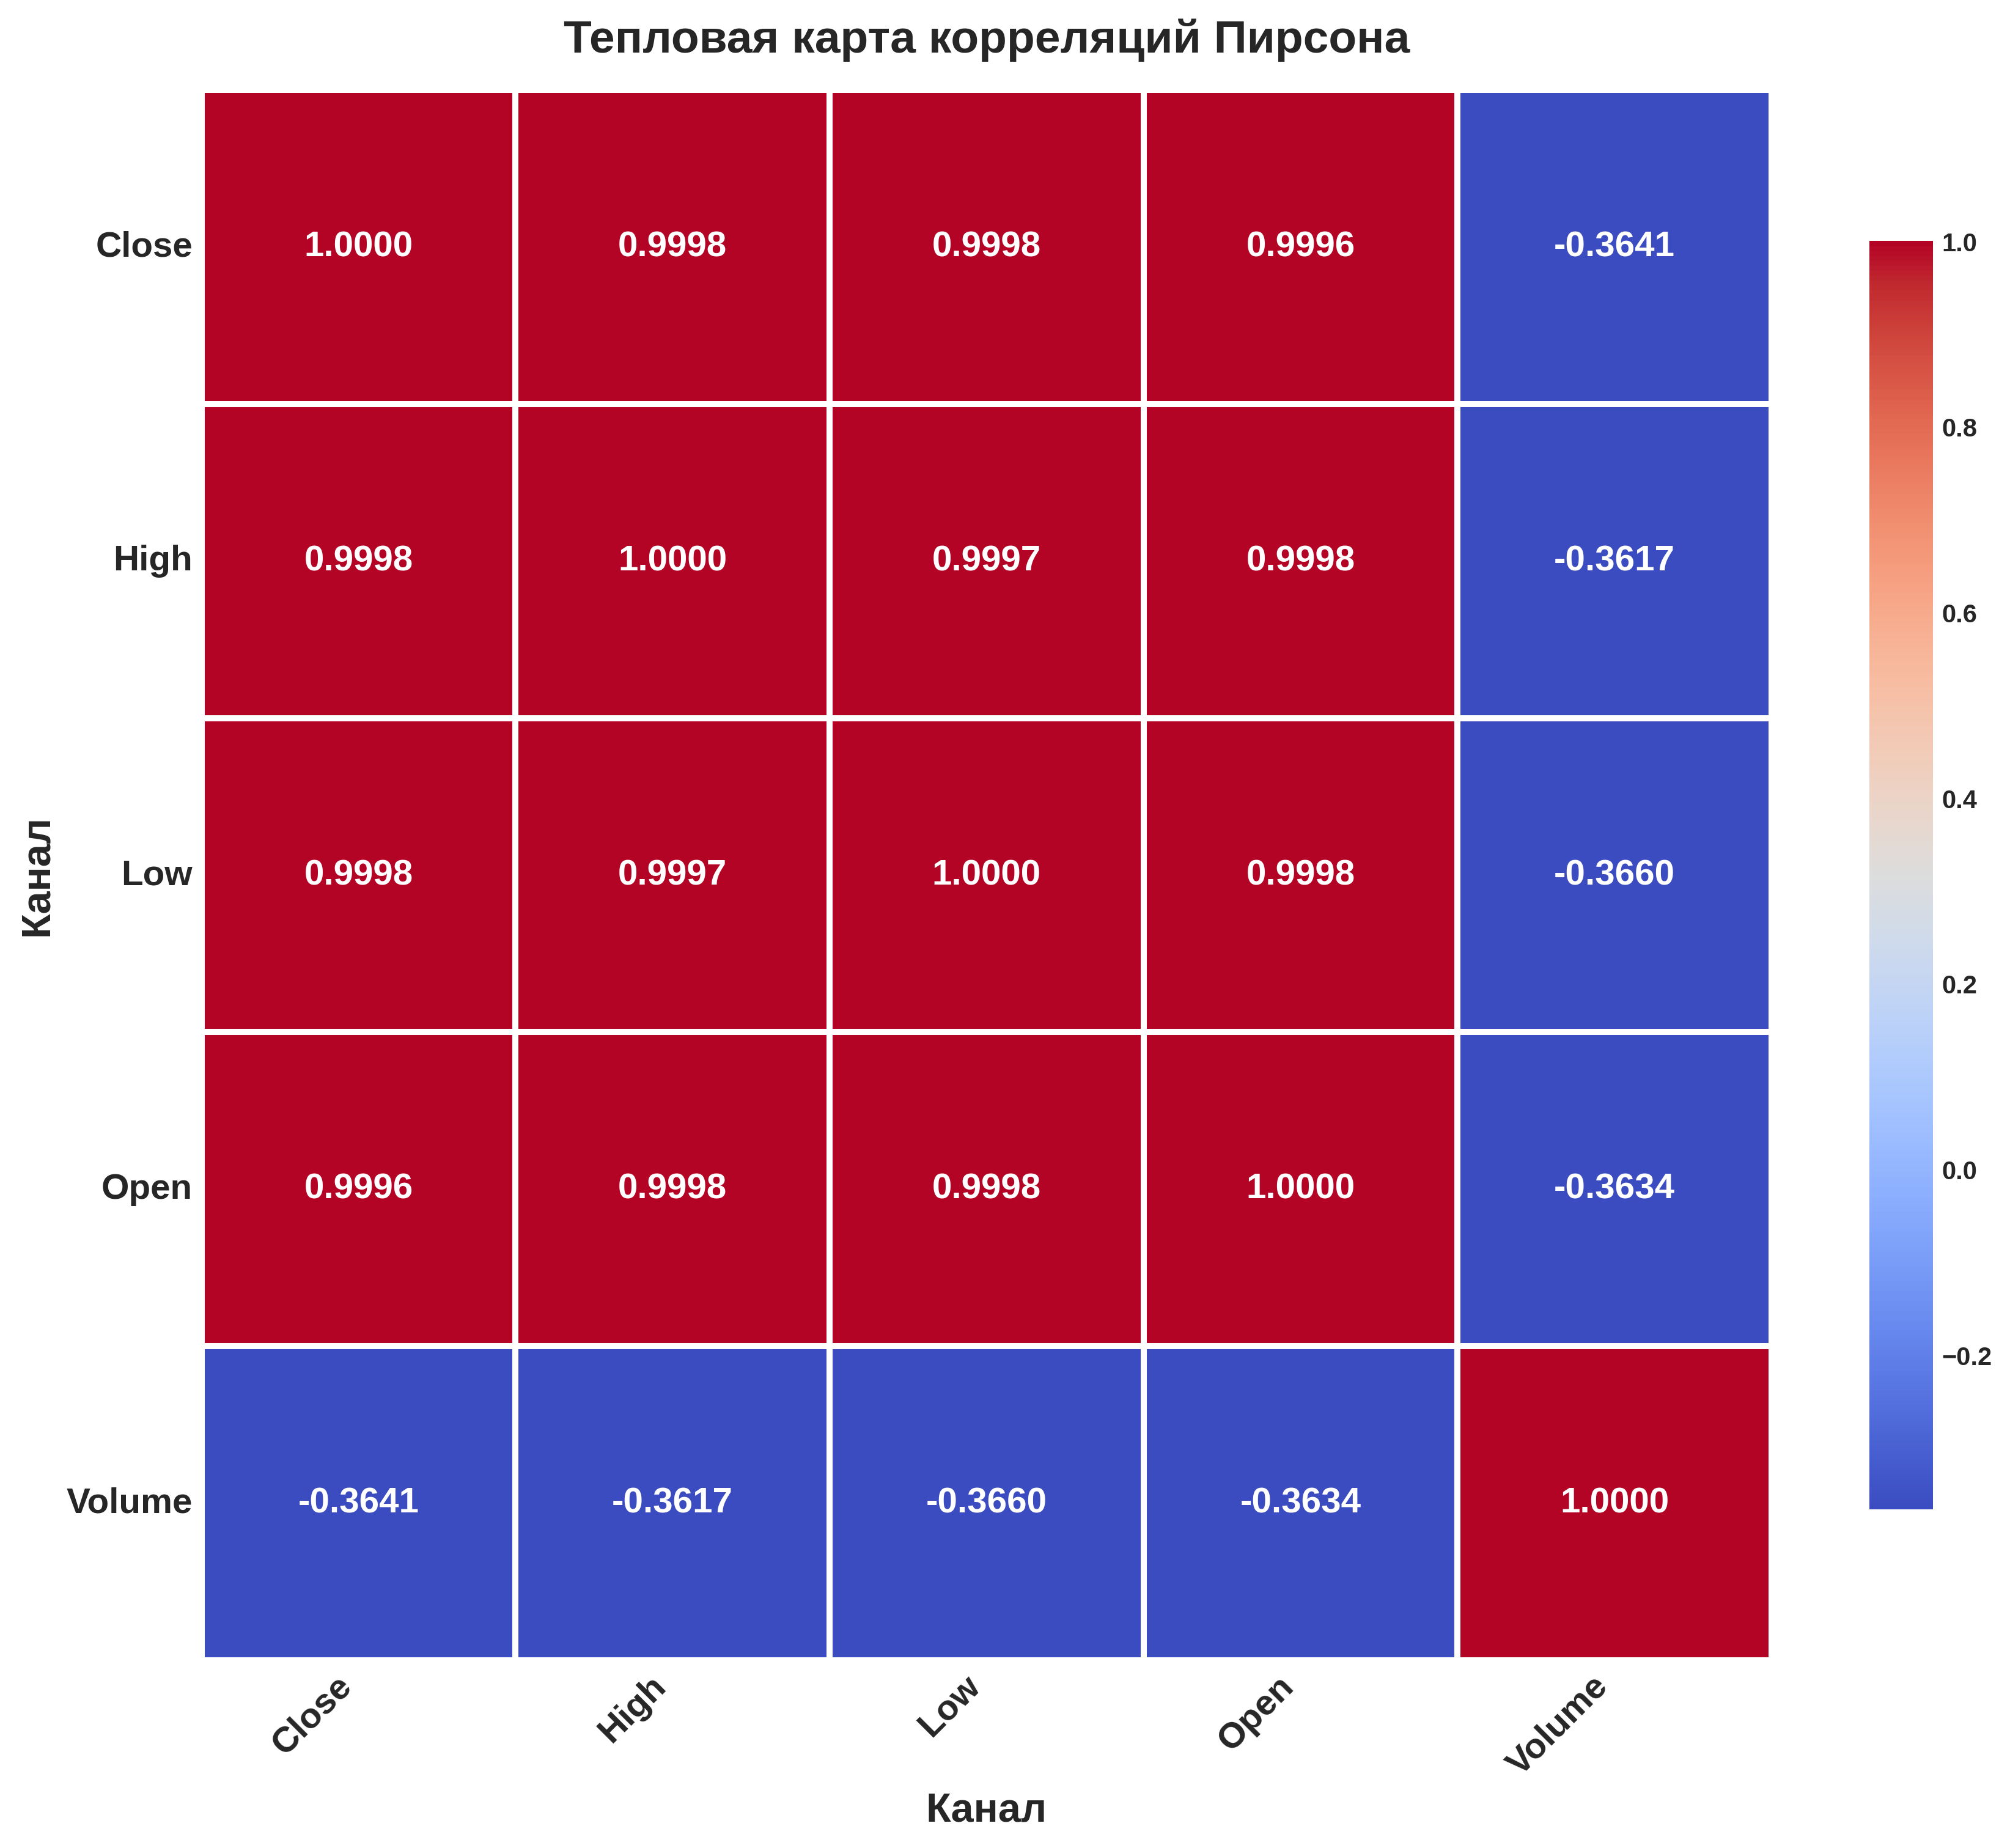

✅ Рисунок 3.5 сохранён: рисунок_3_5_тепловая_карта_корреляций.png

 Таблица 3.4 — Корреляция каналов с целевой переменной Close
High      0.9998
Low       0.9998
Open      0.9996
Volume   -0.3641
Name: Close, dtype: float64


In [15]:
# =============================================================================
# РИСУНОК 3.5: ТЕПЛОВАЯ КАРТА КОРРЕЛЯЦИЙ ПИРСОНА
# =============================================================================

print("\n Генерация рисунка 3.5 — Тепловая карта корреляций")

corr_matrix = df.corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='coolwarm',
            square=True, linewidths=2, linecolor='white',
            annot_kws={'weight': 'bold', 'size': 14},
            cbar_kws={'shrink': 0.8})

plt.title('Тепловая карта корреляций Пирсона', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Канал', fontsize=16, fontweight='bold')
plt.ylabel('Канал', fontsize=16, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold', rotation=45, ha='right')
plt.yticks(fontsize=14, fontweight='bold', rotation=0)
plt.tight_layout()

# Сохраняем с русским названием и нумерацией по разделу 3.5
chart_path = 'рисунок_3_5_тепловая_карта_корреляций.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Рисунок 3.5 сохранён: {chart_path}")

# Таблица 3.4 — Корреляция каналов с целевой переменной Close
print("\n Таблица 3.4 — Корреляция каналов с целевой переменной Close")
corr_with_close = df.corr()['Close'].drop('Close')
print(corr_with_close.round(4))

###ЯЧЕЙКА 8: Рисунок 3.6 — Декомпозиция временного ряда


 Генерация рисунка 3.6 — Декомпозиция временного ряда


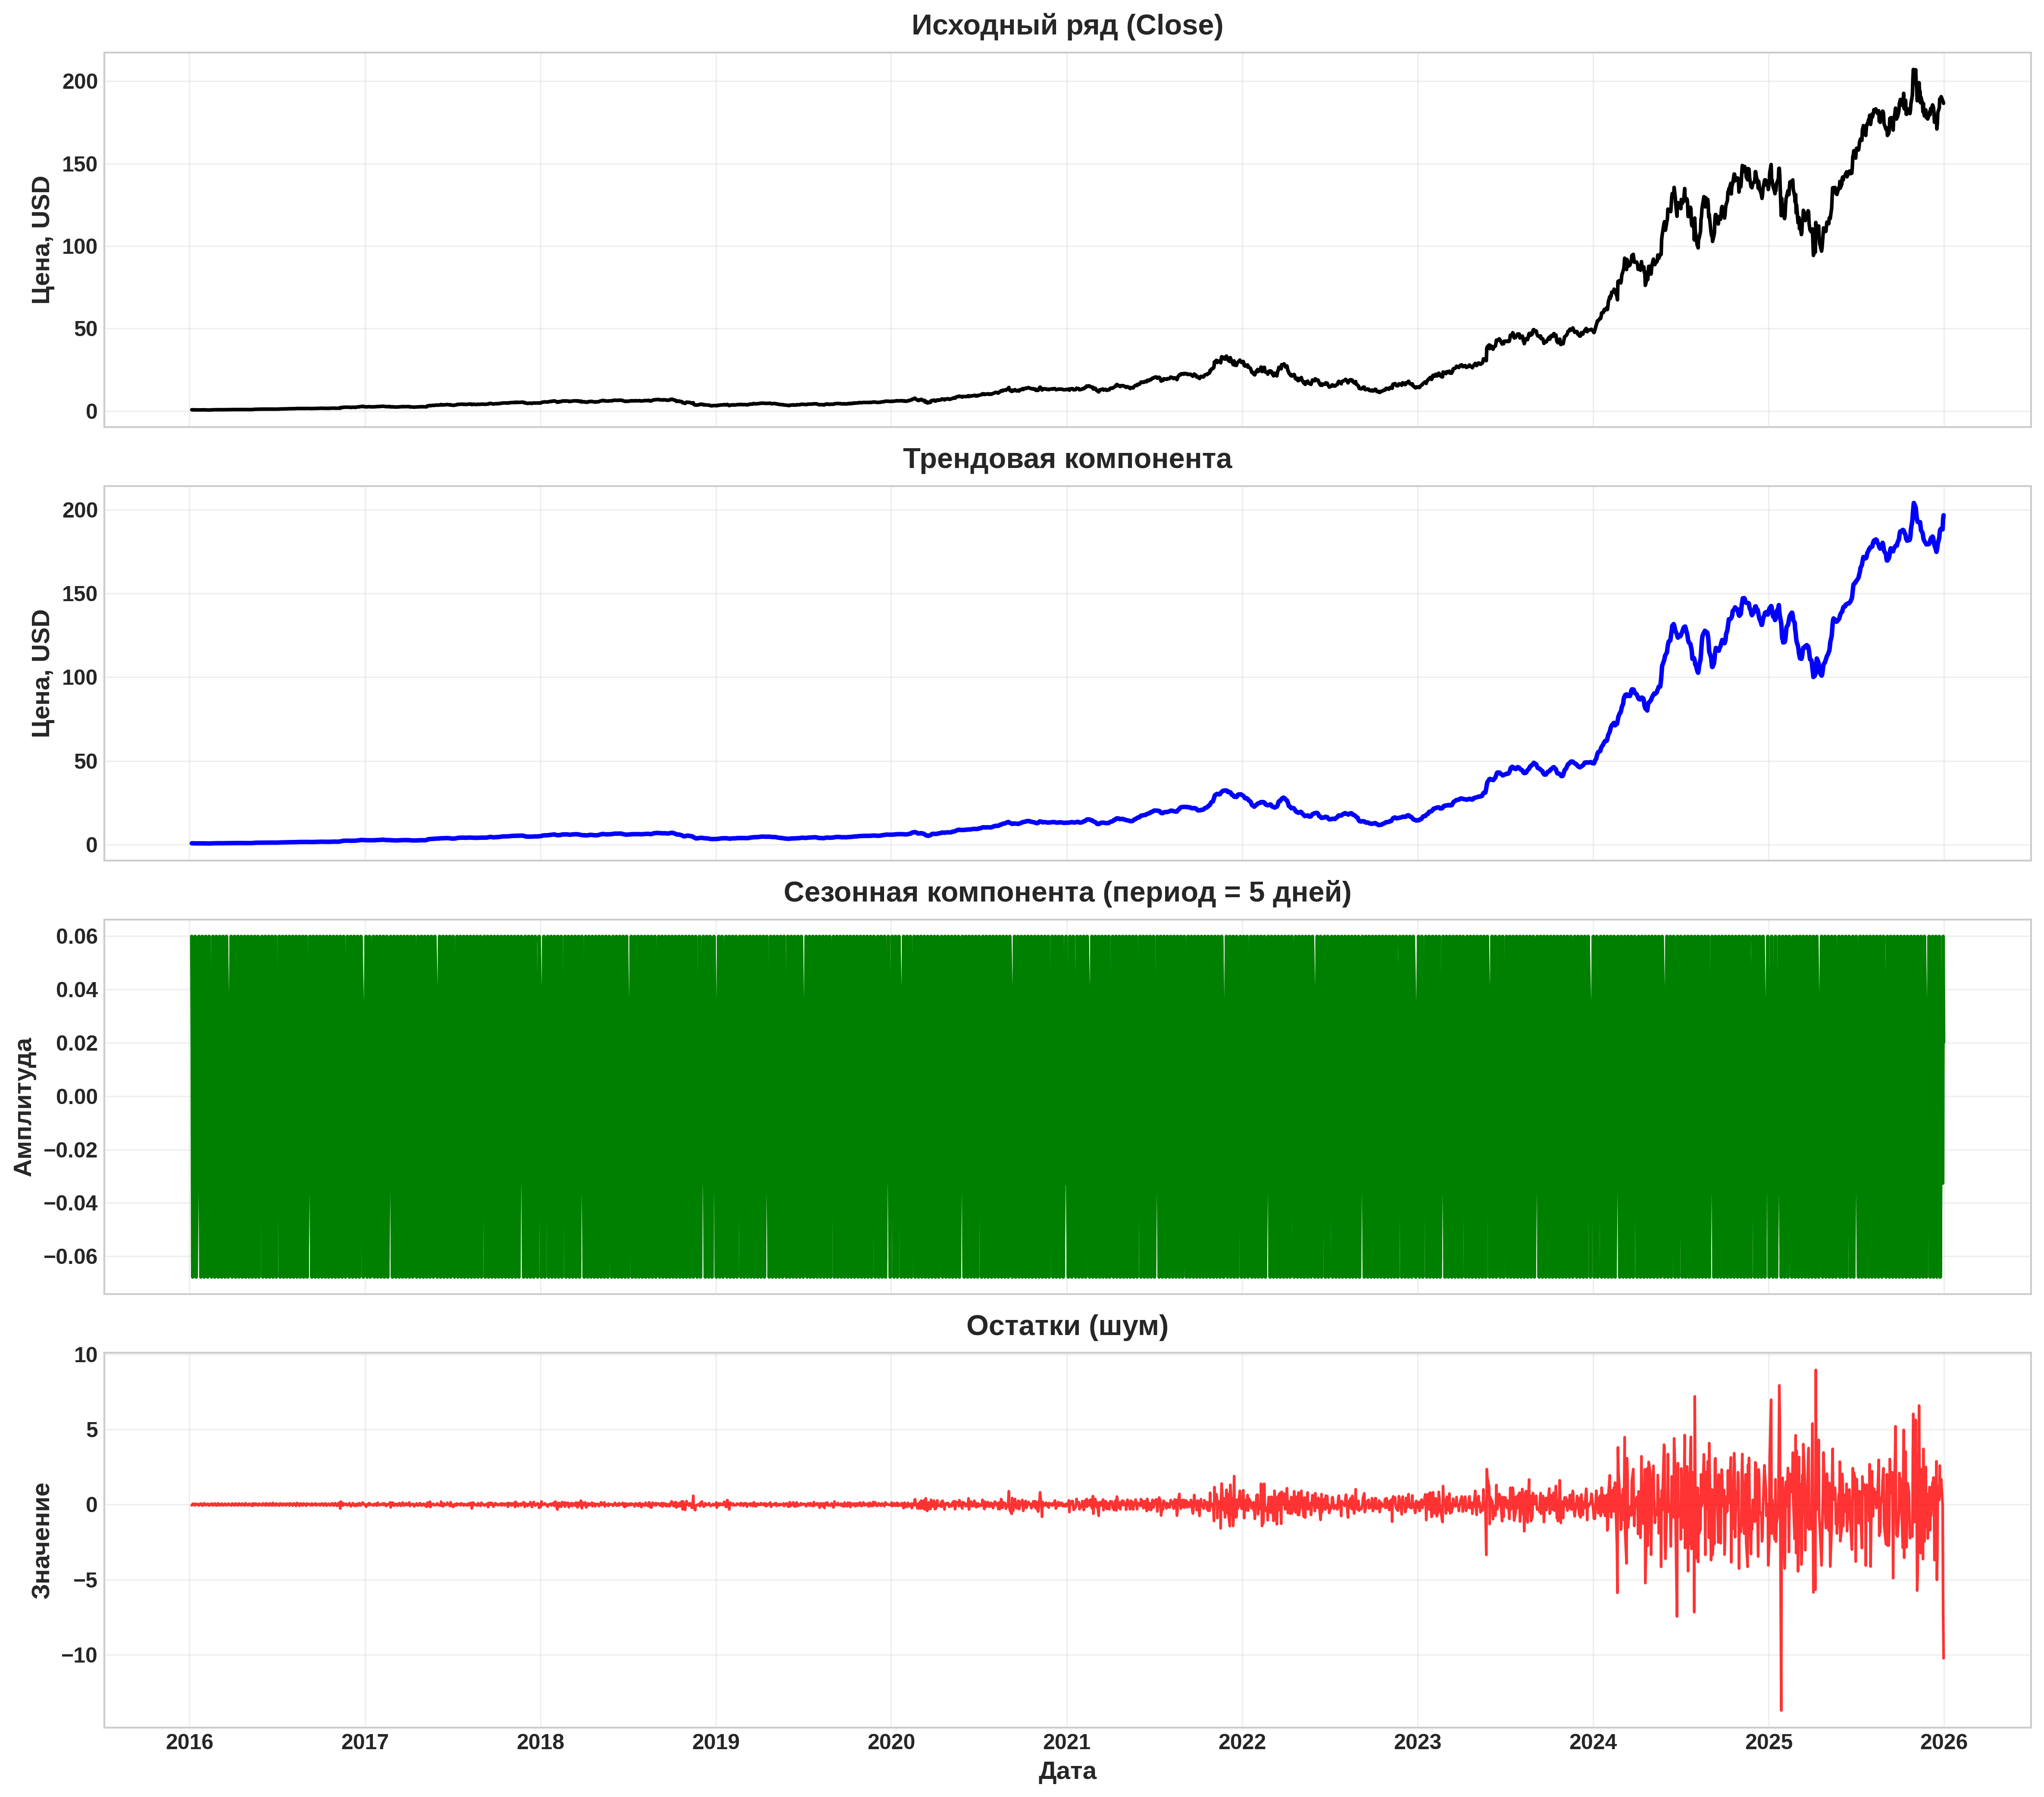

✅ Рисунок 3.6 сохранён: рисунок_3_6_декомпозиция_ряда.png


In [16]:
# =============================================================================
# РИСУНОК 3.6: ДЕКОМПОЗИЦИЯ ВРЕМЕННОГО РЯДА
# =============================================================================

print("\n Генерация рисунка 3.6 — Декомпозиция временного ряда")

from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df['Close'], model='additive', period=5, extrapolate_trend='freq')

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

ax1.plot(decomp.observed, linewidth=2, color='black')
ax1.set_title('Исходный ряд (Close)', fontsize=16, fontweight='bold', pad=10)
ax1.set_ylabel('Цена, USD', fontsize=14, fontweight='bold')
ax1.tick_params(labelsize=12)
ax1.grid(True, alpha=0.3)

ax2.plot(decomp.trend, linewidth=2.5, color='blue')
ax2.set_title('Трендовая компонента', fontsize=16, fontweight='bold', pad=10)
ax2.set_ylabel('Цена, USD', fontsize=14, fontweight='bold')
ax2.tick_params(labelsize=12)
ax2.grid(True, alpha=0.3)

ax3.plot(decomp.seasonal, linewidth=2, color='green')
ax3.set_title('Сезонная компонента (период = 5 дней)', fontsize=16, fontweight='bold', pad=10)
ax3.set_ylabel('Амплитуда', fontsize=14, fontweight='bold')
ax3.tick_params(labelsize=12)
ax3.grid(True, alpha=0.3)

ax4.plot(decomp.resid, linewidth=1.5, color='red', alpha=0.8)
ax4.set_title('Остатки (шум)', fontsize=16, fontweight='bold', pad=10)
ax4.set_ylabel('Значение', fontsize=14, fontweight='bold')
ax4.set_xlabel('Дата', fontsize=14, fontweight='bold')
ax4.tick_params(labelsize=12)
ax4.grid(True, alpha=0.3)

plt.tight_layout()

# Сохраняем с русским названием и нумерацией по разделу 3.6
chart_path = 'рисунок_3_6_декомпозиция_ряда.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Рисунок 3.6 сохранён: {chart_path}")

###ЯЧЕЙКА 9: Рисунок 3.7 — Гистограмма распределения остатков (шума)


📊 Генерация рисунка 3.7 — Гистограмма распределения остатков
Среднее: -0.01
Стд. отклонение: 1.13
Мин: -13.70, Макс: 8.95


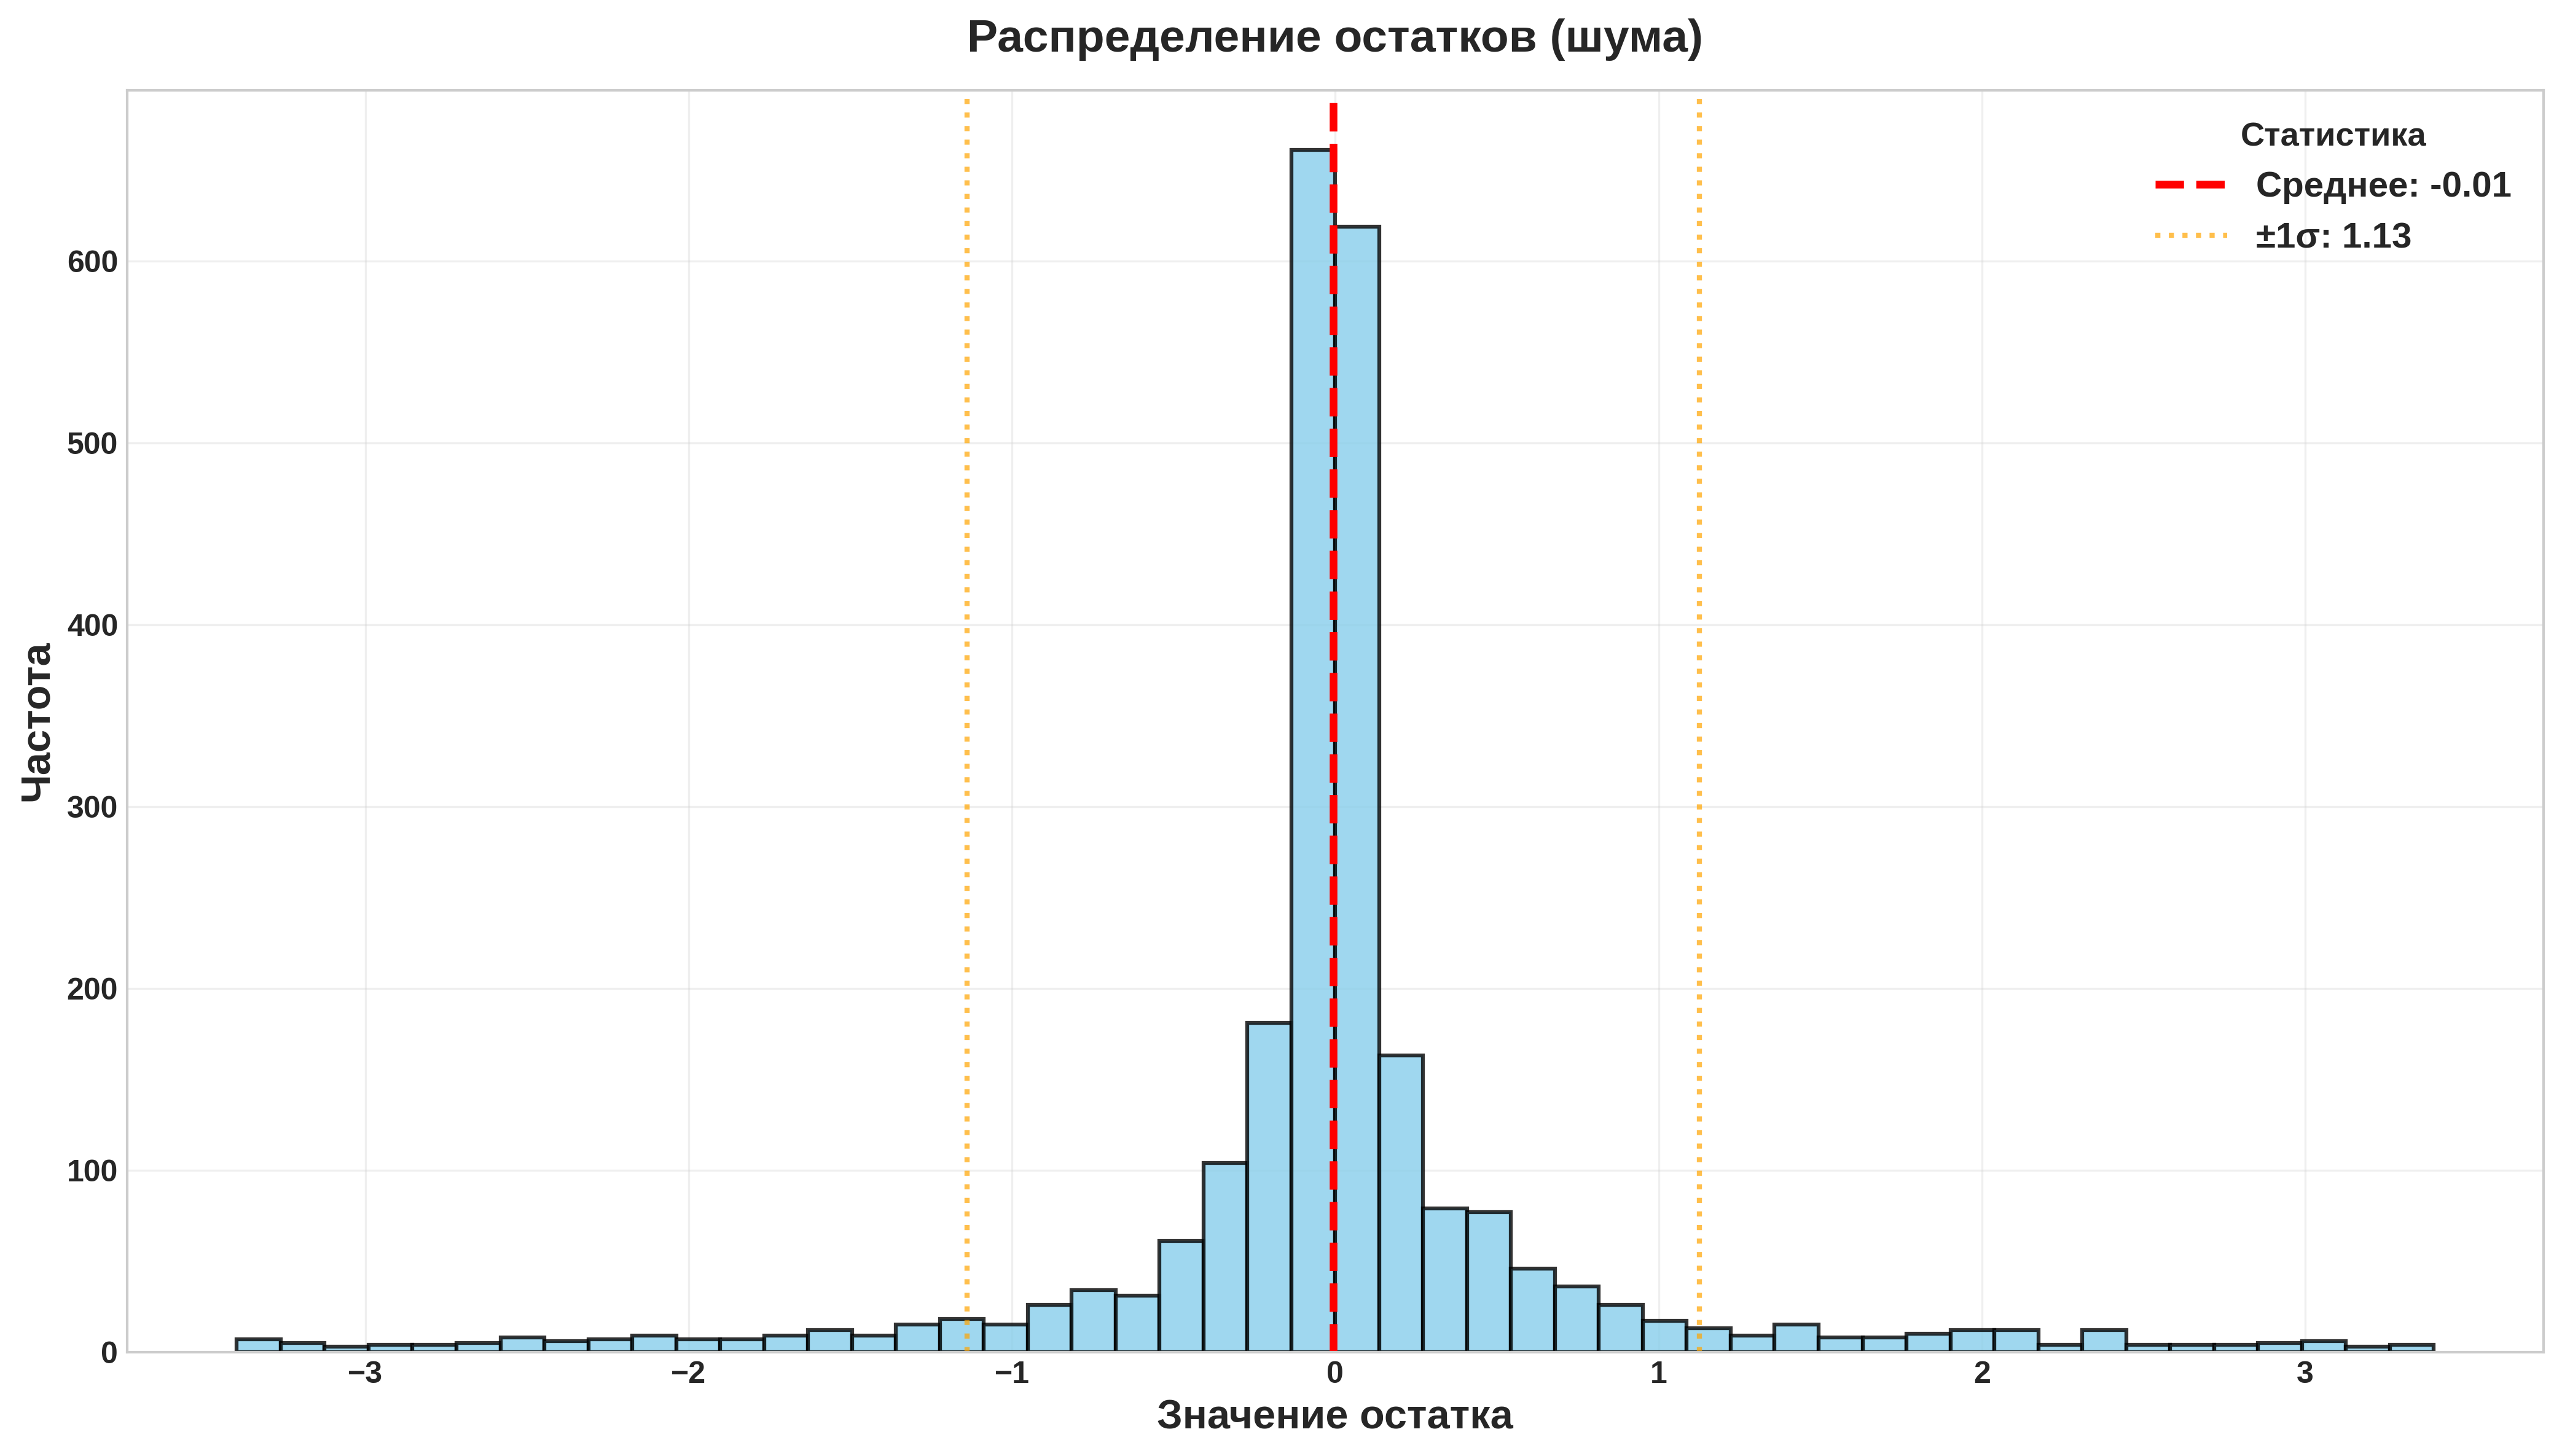


✅ Рисунок 3.7 сохранён: рисунок_3_7_гистограмма_остатков.png


In [17]:
# =============================================================================
# РИСУНОК 3.7: ГИСТОГРАММА РАСПРЕДЕЛЕНИЯ ОСТАТКОВ (ШУМА)
# =============================================================================

print("\n📊 Генерация рисунка 3.7 — Гистограмма распределения остатков")

signal = decomp.trend + decomp.seasonal
noise = decomp.resid
noise_clean = noise.dropna()

# Статистика для отображения
mean_val = noise_clean.mean()
std_val = noise_clean.std()
print(f"Среднее: {mean_val:.2f}")
print(f"Стд. отклонение: {std_val:.2f}")
print(f"Мин: {noise_clean.min():.2f}, Макс: {noise_clean.max():.2f}")

plt.figure(figsize=(14, 8))

# Используем диапазон ±3 стандартных отклонения для лучшего отображения
display_range = (-3*std_val, 3*std_val)

plt.hist(noise_clean, bins=50, edgecolor='black', alpha=0.8, color='skyblue',
         linewidth=1.5, range=display_range)

plt.axvline(x=mean_val, color='red', linestyle='--', linewidth=3,
            label=f'Среднее: {mean_val:.2f}')
plt.axvline(x=mean_val - std_val, color='orange', linestyle=':', linewidth=2,
            label=f'±1σ: {std_val:.2f}', alpha=0.7)
plt.axvline(x=mean_val + std_val, color='orange', linestyle=':', linewidth=2, alpha=0.7)

plt.title('Распределение остатков (шума)', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Значение остатка', fontsize=16, fontweight='bold')
plt.ylabel('Частота', fontsize=16, fontweight='bold')
plt.legend(fontsize=14, title='Статистика', title_fontsize=13, loc='upper right')
plt.tick_params(axis='both', labelsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Сохраняем с русским названием и нумерацией по разделу 3.7
chart_path = 'рисунок_3_7_гистограмма_остатков.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✅ Рисунок 3.7 сохранён: {chart_path}")

###ЯЧЕЙКА 10: Расчёт SNR, kurtosis и skewness

In [18]:
# =============================================================================
# РАСЧЁТ SNR, KURTOSIS И SKEWNESS
# =============================================================================

print("\n" + "="*60)
print("РАСЧЁТ SNR, KURTOSIS И SKEWNESS")
print("="*60)

from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np
from scipy import stats

# Декомпозиция ряда Close
result = seasonal_decompose(df['Close'], model='additive', period=5)

# Сигнал и шум
signal = result.trend + result.seasonal
noise = result.resid.dropna()

# Расчёт SNR
signal_var = np.var(signal.dropna())
noise_var = np.var(noise)
snr = 10 * np.log10(signal_var / noise_var)

print(f"Дисперсия сигнала: {signal_var:.2f}")
print(f"Дисперсия шума: {noise_var:.2f}")
print(f"SNR: {snr:.2f} дБ")

# Расчёт kurtosis и skewness для шума
kurt = stats.kurtosis(noise)
skew = stats.skew(noise)

print(f"\nKurtosis шума: {kurt:.3f}")
print(f"Skewness шума: {skew:.3f}")

# Проверка на нормальность
if abs(kurt) > 1:
    print(f"\n⚠️  Распределение шума имеет тяжёлые хвосты (kurtosis >> 1)")
    print("   Рекомендуется медианный фильтр")
else:
    print(f"\n✓ Распределение шума близко к нормальному")

print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ ДЛЯ ТАБЛИЦЫ 3.5 (ПАСПОРТ ВРЕМЕННОГО РЯДА)")
print("="*60)
print(f"SNR: {snr:.2f} дБ")
print(f"Kurtosis шума: {kurt:.3f}")
print(f"Skewness шума: {skew:.3f}")


РАСЧЁТ SNR, KURTOSIS И SKEWNESS
Дисперсия сигнала: 2603.49
Дисперсия шума: 1.22
SNR: 33.28 дБ

Kurtosis шума: 20.724
Skewness шума: -0.445

⚠️  Распределение шума имеет тяжёлые хвосты (kurtosis >> 1)
   Рекомендуется медианный фильтр

ИТОГОВЫЕ РЕЗУЛЬТАТЫ ДЛЯ ТАБЛИЦЫ 3.5 (ПАСПОРТ ВРЕМЕННОГО РЯДА)
SNR: 33.28 дБ
Kurtosis шума: 20.724
Skewness шума: -0.445
